Loaded studentInfo: 32,593 rows x 13 cols
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'dropout']

A1: Gender distribution


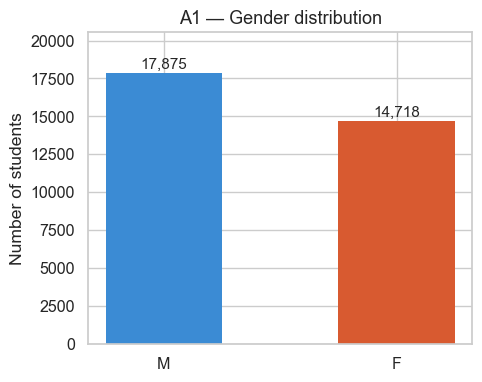

  Saved → ./outputs/block_a/A1_gender.png

gender
M    17875
F    14718 

A2: Age band distribution


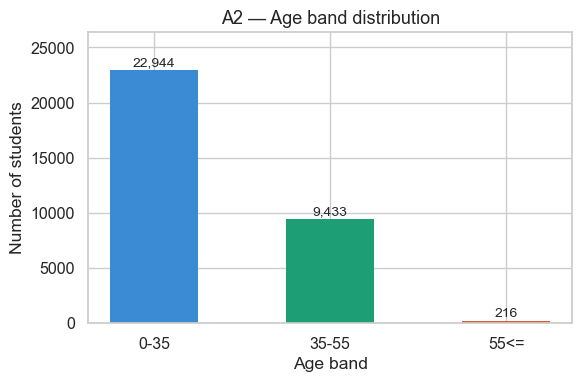

  Saved → ./outputs/block_a/A2_age_band.png

age_band
0-35     22944
35-55     9433
55<=       216 

A3: Highest education level


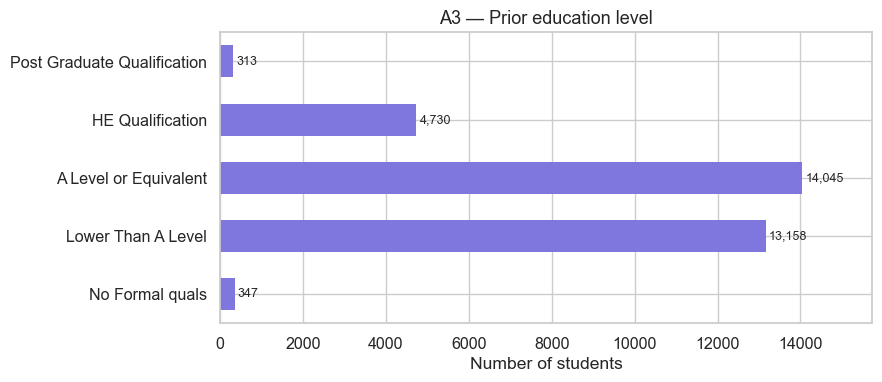

  Saved → ./outputs/block_a/A3_education.png

highest_education
No Formal quals                  347
Lower Than A Level             13158
A Level or Equivalent          14045
HE Qualification                4730
Post Graduate Qualification      313 

A4: IMD band (deprivation index)
  Missing imd_band values: 1,111 (3.4%) — excluded from plot


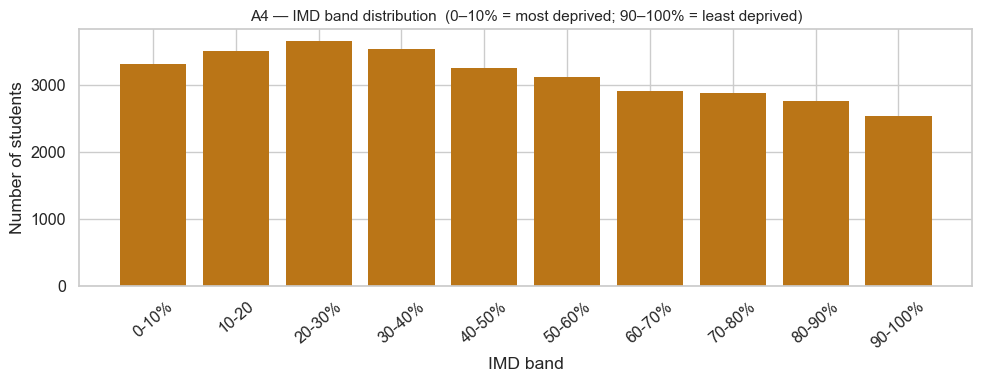

  Saved → ./outputs/block_a/A4_imd_band.png

imd_band
0-10%      3311
10-20      3516
20-30%     3654
30-40%     3539
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536 

A5: Number of previous attempts


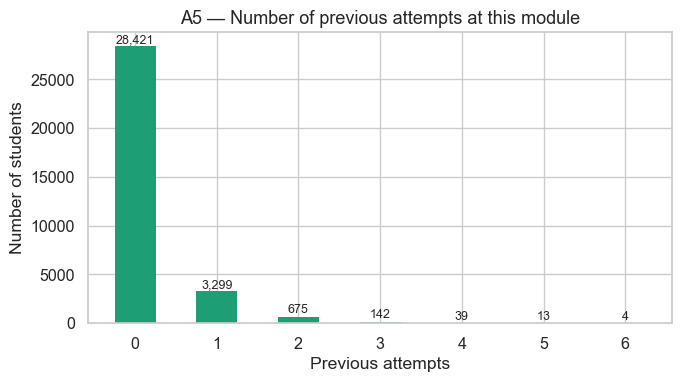

  Saved → ./outputs/block_a/A5_prev_attempts.png

num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4 

A6: Studied credits distribution


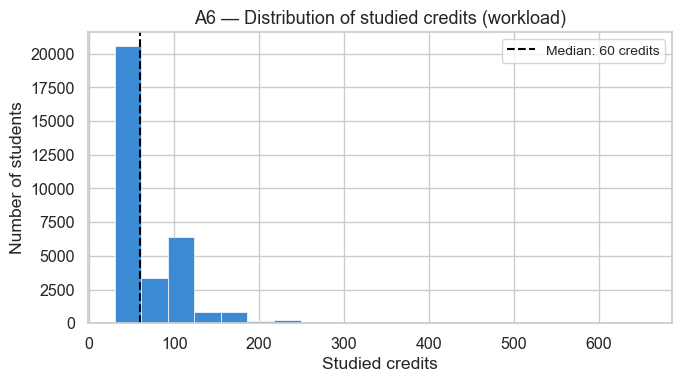

  Saved → ./outputs/block_a/A6_credits.png

count    32593.0
mean        79.8
std         41.1
min         30.0
25%         60.0
50%         60.0
75%        120.0
max        655.0 

A7: Student count by course module


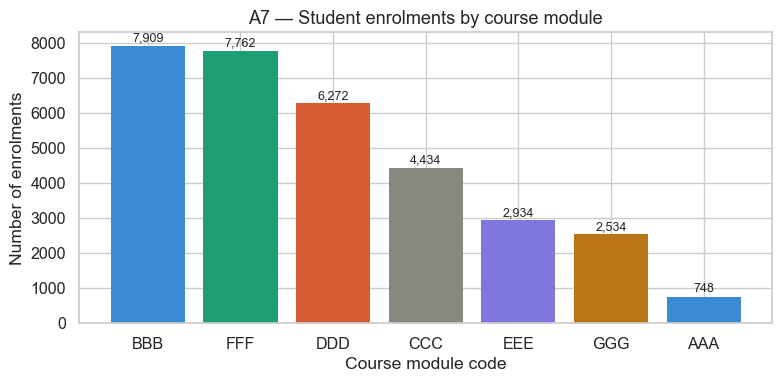

  Saved → ./outputs/block_a/A7_course_module.png

code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748 

BLOCK A COMPLETE — Population Summary

  Total student-course rows : 32,593
  Unique students            : 28,785

  Gender split:
gender
M    17875
F    14718

  Age band split:
age_band
0-35     22944
35-55     9433
55<=       216

  Most common education level: A Level or Equivalent

  IMD band missing           : 1,111 rows (3.4%)

  Studied credits — median   : 60

  All charts saved to: ./outputs/block_a/

─────────────────────────────────────────────────
Next → Run block_b_dropout_rates.py
─────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 2 — Block A: Student Population Distributions
=============================================================
Goal: Understand WHO is in the dataset before we look at dropout.
      We plot distributions for every key demographic and academic
      feature so we know what population we're working with.

"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/block_a/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Consistent colour palette used across all blocks
COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
COLOR_LIST = list(COLORS.values())

# Apply a clean seaborn theme globally
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)


# =============================================================
# LOAD DATA
# =============================================================

# We only need studentInfo for Block A — it has all the demographic
# and academic features we want to distribute-plot.
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')

# Recreate the binary dropout column (needed for later blocks;
# good habit to always have it available)
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

print(f"Loaded studentInfo: {si.shape[0]:,} rows x {si.shape[1]} cols")
print(f"Columns: {list(si.columns)}\n")


# =============================================================
# HELPER: save_plot
# =============================================================
# A small helper so we don't repeat plt.tight_layout() and
# plt.savefig() in every cell.

def save_plot(filename):
    """Tidy layout, save to output folder, and display."""
    plt.tight_layout()
    path = os.path.join(OUTPUT_PATH, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved → {path}\n")


# =============================================================
# A1: Gender distribution
# =============================================================
# Why: If the gender split is very unequal, group-level dropout
# rates in Block B could be misleading (a rare group can look
# extreme just because of small sample size).

print("A1: Gender distribution")

gender_counts = si['gender'].value_counts()   # count M and F

fig, ax = plt.subplots(figsize=(5, 4))

ax.bar(
    gender_counts.index,          # x-axis: M, F
    gender_counts.values,         # bar heights
    color=[COLORS['blue'], COLORS['coral']],
    edgecolor='none',
    width=0.5
)

# Add count labels above each bar so exact numbers are readable
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # centre of bar
        bar.get_height() + 80,                # just above bar
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=11
    )

ax.set_title("A1 — Gender distribution", fontsize=13)
ax.set_ylabel("Number of students")
ax.set_xlabel("")
ax.set_ylim(0, gender_counts.max() * 1.15)   # headroom for labels

save_plot("A1_gender.png")
print(gender_counts.to_string(), "\n")


# =============================================================
# A2: Age band distribution
# =============================================================
# Why: Age can proxy for life stage. Mature students (35+) may have
# more competing demands (jobs, childcare) that raise dropout risk.
# OULAD uses 3 bands rather than exact ages.

print("A2: Age band distribution")

# Define a logical order for the bars (youngest → oldest)
age_order  = ['0-35', '35-55', '55<=']
age_counts = si['age_band'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    age_counts.index,
    age_counts.values,
    color=COLOR_LIST[:3],
    edgecolor='none',
    width=0.5
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=10
    )

ax.set_title("A2 — Age band distribution", fontsize=13)
ax.set_ylabel("Number of students")
ax.set_xlabel("Age band")
ax.set_ylim(0, age_counts.max() * 1.15)

save_plot("A2_age_band.png")
print(age_counts.to_string(), "\n")


# =============================================================
# A3: Highest education level
# =============================================================
# Why: Prior qualifications are one of the strongest predictors
# of academic success. Students entering with lower qualifications
# may find university-level material harder.
#
# We use a HORIZONTAL bar chart here because the category labels
# are long — horizontal bars avoid cluttered x-axis text.

print("A3: Highest education level")

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

edu_counts = si['highest_education'].value_counts().reindex(edu_order)

fig, ax = plt.subplots(figsize=(9, 4))

ax.barh(
    edu_counts.index,
    edu_counts.values,
    color=COLORS['purple'],
    edgecolor='none',
    height=0.55
)

# Add labels at the end of each horizontal bar
for bar in ax.patches:
    ax.text(
        bar.get_width() + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va='center', fontsize=9
    )

ax.set_title("A3 — Prior education level", fontsize=13)
ax.set_xlabel("Number of students")
ax.set_xlim(0, edu_counts.max() * 1.12)

save_plot("A3_education.png")
print(edu_counts.to_string(), "\n")


# =============================================================
# A4: IMD band (deprivation index)
# =============================================================
# Why: IMD = Index of Multiple Deprivation. It ranks neighbourhoods
# by deprivation (income, employment, health, education, etc.).
# 0-10% = most deprived. This is a socioeconomic proxy — students
# from deprived areas may face resource barriers that affect study.
#
# NOTE: imd_band has ~5% missing values. We drop them for this plot
# and flag the count so we don't forget to handle them later.

print("A4: IMD band (deprivation index)")

imd_order = [
    '0-10%', '10-20', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]

# dropna() excludes missing values from the count
imd_counts = si['imd_band'].value_counts().reindex(imd_order).dropna()

# Report how many are missing so it's on record
n_missing_imd = si['imd_band'].isnull().sum()
print(f"  Missing imd_band values: {n_missing_imd:,} "
      f"({n_missing_imd / len(si) * 100:.1f}%) — excluded from plot")

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    imd_counts.index,
    imd_counts.values,
    color=COLORS['amber'],
    edgecolor='none'
)

ax.set_title(
    "A4 — IMD band distribution  (0–10% = most deprived; 90–100% = least deprived)",
    fontsize=11
)
ax.set_ylabel("Number of students")
ax.set_xlabel("IMD band")
ax.tick_params(axis='x', rotation=40)

save_plot("A4_imd_band.png")
print(imd_counts.to_string(), "\n")


# =============================================================
# A5: Number of previous attempts
# =============================================================
# Why: This tells us how many times a student has tried THIS module
# before. Repeat attempts might indicate persistent difficulty,
# which could signal higher future dropout risk.

print("A5: Number of previous attempts")

attempt_counts = si['num_of_prev_attempts'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    attempt_counts.index.astype(str),   # convert to string for cleaner x labels
    attempt_counts.values,
    color=COLORS['teal'],
    edgecolor='none',
    width=0.5
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title("A5 — Number of previous attempts at this module", fontsize=13)
ax.set_ylabel("Number of students")
ax.set_xlabel("Previous attempts")

save_plot("A5_prev_attempts.png")
print(attempt_counts.to_string(), "\n")


# =============================================================
# A6: Studied credits (workload)
# =============================================================
# Why: studied_credits reflects how heavy a student's workload is.
# We use a histogram (not a bar chart) because credits is a continuous
# numeric variable. A skewed distribution here might mean most students
# take lighter loads, with a tail of very intensive courses.

print("A6: Studied credits distribution")

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    si['studied_credits'],
    bins=20,                    # 20 equal-width bins across the range
    color=COLORS['blue'],
    edgecolor='white',
    linewidth=0.5
)

# Draw a vertical dashed line at the median credit load
median_credits = si['studied_credits'].median()
ax.axvline(
    median_credits,
    color='black', linestyle='--', linewidth=1.5,
    label=f'Median: {int(median_credits)} credits'
)

ax.set_title("A6 — Distribution of studied credits (workload)", fontsize=13)
ax.set_ylabel("Number of students")
ax.set_xlabel("Studied credits")
ax.legend(fontsize=10)

save_plot("A6_credits.png")

# Print summary statistics so we have the numbers on record
print(si['studied_credits'].describe().round(1).to_string(), "\n")


# =============================================================
# A7: Course module breakdown
# =============================================================
# Why: OULAD covers 7 different course modules (coded as letters).
# If one module has many more students than others, it could dominate
# our model's behaviour. We also check if courses are balanced.

print("A7: Student count by course module")

module_counts = si['code_module'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    module_counts.index,
    module_counts.values,
    color=COLOR_LIST,
    edgecolor='none'
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title("A7 — Student enrollments by course module", fontsize=13)
ax.set_ylabel("Number of enrolments")
ax.set_xlabel("Course module code")

save_plot("A7_course_module.png")
print(module_counts.to_string(), "\n")


# =============================================================
# BLOCK A SUMMARY
# =============================================================
print("=" * 55)
print("BLOCK A COMPLETE — Population Summary")
print("=" * 55)
print(f"""
  Total student-course rows : {len(si):,}
  Unique students            : {si['id_student'].nunique():,}

  Gender split:
{si['gender'].value_counts().to_string()}

  Age band split:
{si['age_band'].value_counts().reindex(age_order).to_string()}

  Most common education level: {si['highest_education'].mode()[0]}

  IMD band missing           : {n_missing_imd:,} rows ({n_missing_imd/len(si)*100:.1f}%)

  Studied credits — median   : {int(si['studied_credits'].median())}

  All charts saved to: {OUTPUT_PATH}

─────────────────────────────────────────────────
Next → Run block_b_dropout_rates.py
─────────────────────────────────────────────────
""")